In [1]:
# Core Data Manipulation & Numerical Operations
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Inline plotting configuration for Jupyter Notebook
%matplotlib inline

# Optional: Statistical Analysis & Machine Learning (if you plan to build predictive models later)
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('healthcare_dataset.csv')

# Display the first 5 rows to verify import
display(df.head())

# Check basic info (data types, non-null counts)
df.info()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [3]:
# Check for missing values count and percentage
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100

# Combine into a summary DataFrame
null_summary = pd.DataFrame({
    'Missing Values': null_counts, 
    'Percentage (%)': null_percentages
})

# Display columns that have missing values
print(null_summary[null_summary['Missing Values'] > 0])

Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []


In [4]:
# Check for duplicate rows across the entire dataframe
duplicates_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates_count}")

# Optional: If you want to drop duplicates and keep the first occurrence
# df = df.drop_duplicates()

Total duplicate rows: 534


In [5]:
# Drop duplicate rows and reset the index
df = df.drop_duplicates().reset_index(drop=True)

# Verify the new shape of the dataframe
print(f"New dataset shape after removing duplicates: {df.shape}")

New dataset shape after removing duplicates: (54966, 15)


In [6]:
# Check for duplicate rows across the entire dataframe
duplicates_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates_count}")

# Optional: If you want to drop duplicates and keep the first occurrence
# df = df.drop_duplicates()

Total duplicate rows: 0


In [7]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54966 entries, 0 to 54965
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                54966 non-null  object 
 1   Age                 54966 non-null  int64  
 2   Gender              54966 non-null  object 
 3   Blood Type          54966 non-null  object 
 4   Medical Condition   54966 non-null  object 
 5   Date of Admission   54966 non-null  object 
 6   Doctor              54966 non-null  object 
 7   Hospital            54966 non-null  object 
 8   Insurance Provider  54966 non-null  object 
 9   Billing Amount      54966 non-null  float64
 10  Room Number         54966 non-null  int64  
 11  Admission Type      54966 non-null  object 
 12  Discharge Date      54966 non-null  object 
 13  Medication          54966 non-null  object 
 14  Test Results        54966 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.3

In [9]:
# Convert date columns to datetime objects
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

# Create a Length of Stay (in days) feature
df['Length_of_Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

# Verify the changes and check basic stats of stay duration
print(df[['Date of Admission', 'Discharge Date', 'Length_of_Stay']].head())
print(df['Length_of_Stay'].describe())

  Date of Admission Discharge Date  Length_of_Stay
0        2024-01-31     2024-02-02               2
1        2019-08-20     2019-08-26               6
2        2022-09-22     2022-10-07              15
3        2020-11-18     2020-12-18              30
4        2022-09-19     2022-10-09              20
count    54966.000000
mean        15.499290
std          8.661471
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length_of_Stay, dtype: float64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54966 entries, 0 to 54965
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                54966 non-null  object        
 1   Age                 54966 non-null  int64         
 2   Gender              54966 non-null  object        
 3   Blood Type          54966 non-null  object        
 4   Medical Condition   54966 non-null  object        
 5   Date of Admission   54966 non-null  datetime64[ns]
 6   Doctor              54966 non-null  object        
 7   Hospital            54966 non-null  object        
 8   Insurance Provider  54966 non-null  object        
 9   Billing Amount      54966 non-null  float64       
 10  Room Number         54966 non-null  int64         
 11  Admission Type      54966 non-null  object        
 12  Discharge Date      54966 non-null  datetime64[ns]
 13  Medication          54966 non-null  object    

In [11]:
import re

def clean_name(name):
    # Optional: Remove common honorific prefixes (case-insensitive) if you want to strip them out completely
    name = re.sub(r'^(Dr\.|Mr\.|Mrs\.|Ms\.)\s*', '', str(name), flags=re.IGNORECASE)
    
    # Convert to standard title case (e.g., "Bobby Jackson")
    return name.title()

# Apply the cleaning function to the Name column
df['Name'] = df['Name'].apply(clean_name)

# Verify the cleaned names
print(df['Name'].head(10))

0         Bobby Jackson
1          Leslie Terry
2           Danny Smith
3          Andrew Watts
4         Adrienne Bell
5         Emily Johnson
6        Edward Edwards
7    Christina Martinez
8       Jasmine Aguilar
9      Christopher Berg
Name: Name, dtype: object


In [12]:
# Round the Billing Amount column to 2 decimal places
df['Billing Amount'] = df['Billing Amount'].round(2)

# Verify the changes
print(df['Billing Amount'].head(10))

0    18856.28
1    33643.33
2    27955.10
3    37909.78
4    14238.32
5    48145.11
6    19580.87
7    45820.46
8    50119.22
9    19784.63
Name: Billing Amount, dtype: float64


In [13]:
# Remove commas from the Hospital column
df['Hospital'] = df['Hospital'].str.replace(',', '', regex=False)

# Verify the changes
print(df['Hospital'].head(10))

0               Sons and Miller
1                       Kim Inc
2                      Cook PLC
3     Hernandez Rogers and Vang
4                   White-White
5                Nunez-Humphrey
6               Group Middleton
7    Powell Robinson and Valdez
8                 Sons Rich and
9                Padilla-Walker
Name: Hospital, dtype: object


In [14]:
# Remove commas from Hospital names and count unique values
df['Hospital'] = df['Hospital'].str.replace(',', '', regex=False)
num_unique_hospitals = df['Hospital'].nunique()

print(f"Number of distinct hospitals: {num_unique_hospitals}")

Number of distinct hospitals: 39874


In [15]:
import pandas as pd

# Convert to datetime and extract month names
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Month'] = df['Date of Admission'].dt.month
df['Month_Name'] = df['Date of Admission'].dt.strftime('%B')

# Group by month and count patients
monthly_counts = df.groupby(['Month', 'Month_Name']).size().reset_index(name='Patient_Count')
monthly_counts = monthly_counts.sort_values('Month')

# Display the result
print(monthly_counts[['Month_Name', 'Patient_Count']])

   Month_Name  Patient_Count
0     January           4655
1    February           4210
2       March           4622
3       April           4478
4         May           4555
5        June           4650
6        July           4765
7      August           4785
8   September           4508
9     October           4613
10   November           4508
11   December           4617


In [17]:


# Convert to datetime and extract month names
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Month_Name'] = df['Date of Admission'].dt.strftime('%B')

# Get total number of patients
total_patients = len(df)
print(f"Total Number of Patients: {total_patients}")

# Group by month, count patients, and sort in descending order of distinctness/count
monthly_counts = (
    df['Month_Name']
    .value_counts()
    .reset_index()
)
monthly_counts.columns = ['Month_Name', 'Patient_Count']

# Display the sorted result
print(monthly_counts)

Total Number of Patients: 54966
   Month_Name  Patient_Count
0      August           4785
1        July           4765
2     January           4655
3        June           4650
4       March           4622
5    December           4617
6     October           4613
7         May           4555
8   September           4508
9    November           4508
10      April           4478
11   February           4210


In [18]:
# Convert to datetime and extract month info
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Month_Number'] = df['Date of Admission'].dt.month
df['Month_Name'] = df['Date of Admission'].dt.strftime('%B')

# Get total number of patients
total_patients = len(df)
print(f"Total Number of Patients: {total_patients}")

# Group by month, count patients, and sort in descending order of patient counts (distinctiveness)
monthly_counts = (
    df.groupby(['Month_Number', 'Month_Name'])
    .size()
    .reset_index(name='Patient_Count')
    .sort_values(by='Patient_Count', ascending=False)
)

# Display the sorted result
print(monthly_counts[['Month_Name', 'Patient_Count']])

Total Number of Patients: 54966
   Month_Name  Patient_Count
7      August           4785
6        July           4765
0     January           4655
5        June           4650
2       March           4622
11   December           4617
9     October           4613
4         May           4555
8   September           4508
10   November           4508
3       April           4478
1    February           4210


In [20]:
import pandas as pd

# Convert to datetime and extract month info
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Month_Number'] = df['Date of Admission'].dt.month
df['Month_Name'] = df['Date of Admission'].dt.strftime('%B')

# Get total number of patients
total_patients = len(df)
print(f"Total Number of Patients in Whole Year: {total_patients}")

# Group by month and sort chronologically by Month_Number
monthly_counts = (
    df.groupby(['Month_Number', 'Month_Name'])
    .size()
    .reset_index(name='Patient_Count')
    .sort_values(by='Month_Number')
)

# Display the chronologically ordered result
print(monthly_counts[['Month_Name', 'Patient_Count']])

Total Number of Patients in Whole Year: 54966
   Month_Name  Patient_Count
0     January           4655
1    February           4210
2       March           4622
3       April           4478
4         May           4555
5        June           4650
6        July           4765
7      August           4785
8   September           4508
9     October           4613
10   November           4508
11   December           4617


In [21]:
import pandas as pd

# Load the dataset
df = pd.read_csv('healthcare_dataset.csv')

# Calculate distinct counts for each requested column
distinct_blood_types = df['Blood Type'].nunique()
distinct_doctors = df['Doctor'].nunique()
distinct_conditions = df['Medical Condition'].nunique()
distinct_insurance = df['Insurance Provider'].nunique()

# Print the results
print(f"Number of distinct blood types: {distinct_blood_types}")
print(f"Number of distinct doctors: {distinct_doctors}")
print(f"Number of distinct medical conditions: {distinct_conditions}")
print(f"Number of distinct insurance providers: {distinct_insurance}")


Number of distinct blood types: 8
Number of distinct doctors: 40341
Number of distinct medical conditions: 6
Number of distinct insurance providers: 5


In [22]:
# Load the dataset
df = pd.read_csv('healthcare_dataset.csv')

# Get unique names for each category
blood_types = df['Blood Type'].unique().tolist()
doctors = df['Doctor'].unique().tolist()
medical_conditions = df['Medical Condition'].unique().tolist()
insurance_providers = df['Insurance Provider'].unique().tolist()

# Print the names
print("Blood Types:", blood_types)
print("\nMedical Conditions:", medical_conditions)
print("\nInsurance Providers:", insurance_providers)
print("\nFirst 10 Doctors (out of total):", doctors[:10])

Blood Types: ['B-', 'A+', 'A-', 'O+', 'AB+', 'AB-', 'B+', 'O-']

Medical Conditions: ['Cancer', 'Obesity', 'Diabetes', 'Asthma', 'Hypertension', 'Arthritis']

Insurance Providers: ['Blue Cross', 'Medicare', 'Aetna', 'UnitedHealthcare', 'Cigna']

First 10 Doctors (out of total): ['Matthew Smith', 'Samantha Davies', 'Tiffany Mitchell', 'Kevin Wells', 'Kathleen Hanna', 'Taylor Newton', 'Kelly Olson', 'Suzanne Thomas', 'Daniel Ferguson', 'Heather Day']


In [23]:
# Load dataset and clean duplicates
df = pd.read_csv('healthcare_dataset.csv')
df = df.drop_duplicates().reset_index(drop=True)

# 1. Summary statistics for Age
print("--- Age Statistics ---")
print(df['Age'].describe())

# 2. Gender distribution
print("\n--- Gender Distribution ---")
print(df['Gender'].value_counts())

# 3. Create Age Groups (e.g., Under 18, 18-35, 36-50, 51-65, 65+)
bins = [0, 18, 35, 50, 65, 100]
labels = ['Under 18', '18-35', '36-50', '51-65', '65+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

print("\n--- Patient Count by Age Group ---")
print(df['Age_Group'].value_counts().sort_index())

# 4. Cross-tabulation of Age Groups vs Gender
print("\n--- Age Group Breakdown by Gender ---")
print(pd.crosstab(df['Age_Group'], df['Gender']))

--- Age Statistics ---
count    54966.000000
mean        51.535185
std         19.605661
min         13.000000
25%         35.000000
50%         52.000000
75%         68.000000
max         89.000000
Name: Age, dtype: float64

--- Gender Distribution ---
Gender
Male      27496
Female    27470
Name: count, dtype: int64

--- Patient Count by Age Group ---
Age_Group
Under 18      886
18-35       13519
36-50       12167
51-65       12298
65+         16096
Name: count, dtype: int64

--- Age Group Breakdown by Gender ---
Gender     Female  Male
Age_Group              
Under 18      453   433
18-35        6778  6741
36-50        6054  6113
51-65        6074  6224
65+          8111  7985


In [24]:
import pandas as pd

# Load dataset and clean duplicates
df = pd.read_csv('healthcare_dataset.csv')
df = df.drop_duplicates().reset_index(drop=True)

# 1. Summary Statistics for Age
print("==========================================")
print("           PATIENT DEMOGRAPHICS           ")
print("==========================================")
print(f"Total Unique Patients: {len(df):,}")
print(f"Average Age          : {df['Age'].mean():.1f} years")
print(f"Median Age           : {df['Age'].median():.0f} years")
print(f"Age Range            : {df['Age'].min()} - {df['Age'].max()} years\n")

# 2. Gender Distribution
print("--- GENDER DISTRIBUTION ---")
gender_counts = df['Gender'].value_counts()
for gender, count in gender_counts.items():
    pct = (count / len(df)) * 100
    print(f"{gender:10}: {count:,} ({pct:.2f}%)")

# 3. Age Group Breakdown
bins = [0, 18, 35, 50, 65, 100]
labels = ['Under 18', '18-35', '36-50', '51-65', '65+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

print("\n--- AGE GROUP BY GENDER BREAKDOWN ---")
crosstab_df = pd.crosstab(df['Age_Group'], df['Gender'], margins=True)
print(crosstab_df)

           PATIENT DEMOGRAPHICS           
Total Unique Patients: 54,966
Average Age          : 51.5 years
Median Age           : 52 years
Age Range            : 13 - 89 years

--- GENDER DISTRIBUTION ---
Male      : 27,496 (50.02%)
Female    : 27,470 (49.98%)

--- AGE GROUP BY GENDER BREAKDOWN ---
Gender     Female   Male    All
Age_Group                      
Under 18      453    433    886
18-35        6778   6741  13519
36-50        6054   6113  12167
51-65        6074   6224  12298
65+          8111   7985  16096
All         27470  27496  54966


In [25]:
# Load dataset and clean duplicates
df = pd.read_csv('healthcare_dataset.csv')
df = df.drop_duplicates().reset_index(drop=True)

# 1. Blood Type Distribution (Counts and Percentages)
print("--- Blood Type Distribution ---")
blood_counts = df['Blood Type'].value_counts()
blood_pcts = df['Blood Type'].value_counts(normalize=True) * 100
blood_summary = pd.DataFrame({'Count': blood_counts, 'Percentage (%)': blood_pcts.round(2)})
print(blood_summary)

# 2. Cross-tabulation: Blood Type vs Admission Type (Counts)
print("\n--- Blood Type vs Admission Type (Counts) ---")
crosstab_counts = pd.crosstab(df['Blood Type'], df['Admission Type'])
print(crosstab_counts)

# 3. Cross-tabulation: Blood Type vs Admission Type (Normalized Percentages)
print("\n--- Blood Type vs Admission Type (Row Percentages %) ---")
crosstab_pct = pd.crosstab(df['Blood Type'], df['Admission Type'], normalize='index') * 100
print(crosstab_pct.round(2))

--- Blood Type Distribution ---
            Count  Percentage (%)
Blood Type                       
A-           6898           12.55
A+           6896           12.55
B+           6885           12.53
AB+          6882           12.52
AB-          6874           12.51
B-           6872           12.50
O+           6855           12.47
O-           6804           12.38

--- Blood Type vs Admission Type (Counts) ---
Admission Type  Elective  Emergency  Urgent
Blood Type                                 
A+                  2324       2271    2301
A-                  2314       2251    2333
AB+                 2276       2274    2332
AB-                 2365       2241    2268
B+                  2223       2341    2321
B-                  2302       2238    2332
O+                  2307       2284    2264
O-                  2362       2202    2240

--- Blood Type vs Admission Type (Row Percentages %) ---
Admission Type  Elective  Emergency  Urgent
Blood Type                             

In [26]:
# Load dataset and clean duplicates
df = pd.read_csv('healthcare_dataset.csv')
df = df.drop_duplicates().reset_index(drop=True)

# Calculate billing amount metrics
min_billing = df['Billing Amount'].min()
max_billing = df['Billing Amount'].max()
mean_billing = df['Billing Amount'].mean()
median_billing = df['Billing Amount'].median()

# Print formatted output
print("==========================================")
print("       BILLING AMOUNT STATISTICS          ")
print("==========================================")
print(f"Minimum Billing Amount : ${min_billing:,.2f}")
print(f"Maximum Billing Amount : ${max_billing:,.2f}")
print(f"Average (Mean) Billing : ${mean_billing:,.2f}")
print(f"Median Billing Amount  : ${median_billing:,.2f}")


       BILLING AMOUNT STATISTICS          
Minimum Billing Amount : $-2,008.49
Maximum Billing Amount : $52,764.28
Average (Mean) Billing : $25,544.31
Median Billing Amount  : $25,542.75


In [27]:
import pandas as pd

# Load dataset and clean duplicates
df = pd.read_csv('healthcare_dataset.csv')
df = df.drop_duplicates().reset_index(drop=True)

# Group by Medical Condition and calculate billing metrics
billing_by_condition = df.groupby('Medical Condition')['Billing Amount'].agg(
    Count='count',
    Mean_Billing='mean',
    Median_Billing='median',
    Min_Billing='min',
    Max_Billing='max',
    Std_Billing='std'
).reset_index()

# Sort by Mean Billing Amount in descending order
billing_by_condition = billing_by_condition.sort_values(by='Mean_Billing', ascending=False)

# Format the monetary columns for clean viewing
for col in ['Mean_Billing', 'Median_Billing', 'Min_Billing', 'Max_Billing', 'Std_Billing']:
    billing_by_condition[col] = billing_by_condition[col].round(2)

print("--- Billing Amounts by Medical Condition ---")
print(billing_by_condition.to_string(index=False))

--- Billing Amounts by Medical Condition ---
Medical Condition  Count  Mean_Billing  Median_Billing  Min_Billing  Max_Billing  Std_Billing
          Obesity   9146      25804.36        26145.58     -1310.27     52024.73     14082.31
         Diabetes   9216      25660.48        25647.71     -1316.62     52211.85     14152.23
           Asthma   9095      25633.46        25628.41     -1520.42     52181.84     14234.36
        Arthritis   9218      25511.78        25599.18     -1130.00     52170.04     14282.08
     Hypertension   9151      25503.06        25281.63     -1660.01     52764.28     14306.46
           Cancer   9140      25152.32        24910.71     -2008.49     52373.03     14186.94


In [28]:
# Load dataset and clean duplicates
df = pd.read_csv('healthcare_dataset.csv')
df = df.drop_duplicates().reset_index(drop=True)

# 1. Average billing amounts by insurance provider
print("--- Average Billing Amount by Insurance Provider ---")
billing_by_insurance = df.groupby('Insurance Provider')['Billing Amount'].agg(
    Average_Billing='mean',
    Median_Billing='median',
    Total_Patients='count'
).reset_index().sort_values(by='Average_Billing', ascending=False)

# Round monetary values for neat output
billing_by_insurance['Average_Billing'] = billing_by_insurance['Average_Billing'].round(2)
billing_by_insurance['Median_Billing'] = billing_by_insurance['Median_Billing'].round(2)
print(billing_by_insurance.to_string(index=False))

# 2. Volume of emergency admissions by insurance provider
print("\n--- Admission Types by Insurance Provider (Counts) ---")
emergency_by_insurance = pd.crosstab(df['Insurance Provider'], df['Admission Type'], margins=True)
print(emergency_by_insurance)

--- Average Billing Amount by Insurance Provider ---
Insurance Provider  Average_Billing  Median_Billing  Total_Patients
          Medicare         25628.32        25629.33           11039
        Blue Cross         25603.46        25580.54           10952
             Aetna         25549.69        25765.38           10822
             Cigna         25526.00        25537.18           11139
  UnitedHealthcare         25414.51        25222.11           11014

--- Admission Types by Insurance Provider (Counts) ---
Admission Type      Elective  Emergency  Urgent    All
Insurance Provider                                    
Aetna                   3718       3641    3463  10822
Blue Cross              3709       3597    3646  10952
Cigna                   3676       3638    3825  11139
Medicare                3637       3643    3759  11039
UnitedHealthcare        3733       3583    3698  11014
All                    18473      18102   18391  54966


Correlation Coefficient: -0.0049

--- Billing Amount by Length of Stay (Sample) ---
 Length_of_Stay  Patient_Count  Average_Billing  Median_Billing
              1           1808     25332.120731    25184.179707
              2           1830     25275.729178    25396.391822
              3           1828     25916.841521    26650.566373
              4           1848     26003.060271    26349.476372
              5           1819     25472.026206    25633.502381
              6           1889     25919.776421    26019.694127
              7           1864     25773.790664    25671.658422
              8           1807     26094.670590    26097.580251
              9           1856     25570.781016    25463.082135
             10           1788     25439.847493    26184.312082


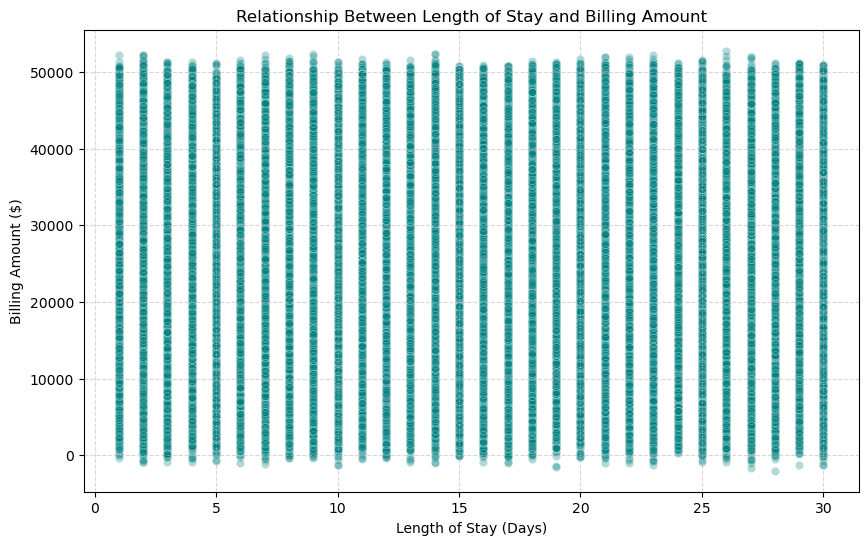

In [29]:
# Load dataset and clean duplicates
df = pd.read_csv('healthcare_dataset.csv')
df = df.drop_duplicates().reset_index(drop=True)

# Convert dates to datetime and compute Length of Stay
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Length_of_Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

# 1. Calculate statistical correlation coefficient
correlation = df['Length_of_Stay'].corr(df['Billing Amount'])
print(f"Correlation Coefficient: {correlation:.4f}")

# 2. Group by Length of Stay to see average/median billing amounts
stay_vs_billing = df.groupby('Length_of_Stay')['Billing Amount'].agg(
    Patient_Count='count',
    Average_Billing='mean',
    Median_Billing='median'
).reset_index()

print("\n--- Billing Amount by Length of Stay (Sample) ---")
print(stay_vs_billing.head(10).to_string(index=False))

# 3. Optional: Scatter plot visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Length_of_Stay', y='Billing Amount', alpha=0.3, color='teal')
plt.title('Relationship Between Length of Stay and Billing Amount')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Billing Amount ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [30]:
# Ensure Date of Admission is datetime
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])

# 1. Monthly Admissions Analysis
df['Month_Name'] = df['Date of Admission'].dt.strftime('%B')
df['Month_Num'] = df['Date of Admission'].dt.month

monthly_admissions = (
    df.groupby(['Month_Num', 'Month_Name'])
    .size()
    .reset_index(name='Patient_Count')
    .sort_values(by='Month_Num')
)

print("--- Monthly Admission Volumes ---")
print(monthly_admissions[['Month_Name', 'Patient_Count']].to_string(index=False))

# 2. Seasonal Admissions Analysis
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month_Num'].apply(get_season)

seasonal_admissions = (
    df.groupby('Season')
    .size()
    .reset_index(name='Patient_Count')
    .sort_values(by='Patient_Count', ascending=False)
)

print("\n--- Seasonal Admission Volumes ---")
print(seasonal_admissions.to_string(index=False))

--- Monthly Admission Volumes ---
Month_Name  Patient_Count
   January           4655
  February           4210
     March           4622
     April           4478
       May           4555
      June           4650
      July           4765
    August           4785
 September           4508
   October           4613
  November           4508
  December           4617

--- Seasonal Admission Volumes ---
Season  Patient_Count
Summer          14200
Spring          13655
  Fall          13629
Winter          13482


In [31]:
# 1. Breakdown of Admission Types (Counts and Percentages)
admission_counts = df['Admission Type'].value_counts()
admission_pcts = df['Admission Type'].value_counts(normalize=True) * 100
admission_summary = pd.DataFrame({'Count': admission_counts, 'Percentage (%)': admission_pcts.round(2)})

print("--- Admission Types Breakdown ---")
print(admission_summary)

# 2. Length of Stay Analysis by Admission Type
stay_by_admission = df.groupby('Admission Type')['Length_of_Stay'].agg(
    Mean_Stay_Days='mean',
    Median_Stay_Days='median',
    Min_Stay_Days='min',
    Max_Stay_Days='max'
).reset_index()

# Round day values for clean presentation
for col in ['Mean_Stay_Days', 'Median_Stay_Days']:
    stay_by_admission[col] = stay_by_admission[col].round(2)

print("\n--- Length of Stay by Admission Type ---")
print(stay_by_admission.to_string(index=False))

--- Admission Types Breakdown ---
                Count  Percentage (%)
Admission Type                       
Elective        18473           33.61
Urgent          18391           33.46
Emergency       18102           32.93

--- Length of Stay by Admission Type ---
Admission Type  Mean_Stay_Days  Median_Stay_Days  Min_Stay_Days  Max_Stay_Days
      Elective           15.51              15.0              1             30
     Emergency           15.58              16.0              1             30
        Urgent           15.40              15.0              1             30


In [32]:
# Group by Hospital, count patient volume, and sort in descending order
top_hospitals = (
    df.groupby('Hospital')
    .size()
    .reset_index(name='Patient_Count')
    .sort_values(by='Patient_Count', ascending=False)
)

print("--- Top Hospitals by Patient Volume ---")
print(top_hospitals.head(10).to_string(index=False))

--- Top Hospitals by Patient Volume ---
   Hospital  Patient_Count
  LLC Smith             44
  Ltd Smith             39
Johnson PLC             37
  Smith Ltd             37
  Smith PLC             36
Smith Group             36
Johnson Inc             34
  Smith Inc             33
  Smith LLC             32
Group Smith             32


In [33]:
# Calculate counts and percentages for diagnostic test results
test_counts = df['Test Results'].value_counts()
test_pcts = df['Test Results'].value_counts(normalize=True) * 100

test_summary = pd.DataFrame({
    'Count': test_counts, 
    'Percentage (%)': test_pcts.round(2)
})

print("--- Diagnostic Test Results Breakdown ---")
print(test_summary)

--- Diagnostic Test Results Breakdown ---
              Count  Percentage (%)
Test Results                       
Abnormal      18437           33.54
Normal        18331           33.35
Inconclusive  18198           33.11


In [34]:
# 1. Medication frequency by Medical Condition (Row Percentages)
med_by_condition = pd.crosstab(
    df['Medical Condition'], 
    df['Medication'], 
    normalize='index'
) * 100

print("--- Medication Distribution by Medical Condition (%) ---")
print(med_by_condition.round(2))

# 2. Medication frequency by Age Group (Row Percentages)
med_by_age = pd.crosstab(
    df['Age_Group'], 
    df['Medication'], 
    normalize='index'
) * 100

print("\n--- Medication Distribution by Age Group (%) ---")
print(med_by_age.round(2))

--- Medication Distribution by Medical Condition (%) ---
Medication         Aspirin  Ibuprofen  Lipitor  Paracetamol  Penicillin
Medical Condition                                                      
Arthritis            20.62      19.58    19.64        20.16       20.00
Asthma               19.58      19.81    19.95        20.56       20.10
Cancer               19.34      20.37    20.83        20.01       19.44
Diabetes             19.92      20.03    20.35        19.47       20.24
Hypertension         20.16      20.48    19.92        20.10       19.34
Obesity              20.26      20.05    19.81        19.41       20.47


KeyError: 'Age_Group'

In [35]:
# Re-create Age_Group to ensure it exists in the dataframe
bins = [0, 18, 35, 50, 65, 100]
labels = ['Under 18', '18-35', '36-50', '51-65', '65+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# 1. Medication frequency by Medical Condition (Row Percentages)
med_by_condition = pd.crosstab(
    df['Medical Condition'], 
    df['Medication'], 
    normalize='index'
) * 100

print("--- Medication Distribution by Medical Condition (%) ---")
print(med_by_condition.round(2))

# 2. Medication frequency by Age Group (Row Percentages)
med_by_age = pd.crosstab(
    df['Age_Group'], 
    df['Medication'], 
    normalize='index'
) * 100

print("\n--- Medication Distribution by Age Group (%) ---")
print(med_by_age.round(2))

--- Medication Distribution by Medical Condition (%) ---
Medication         Aspirin  Ibuprofen  Lipitor  Paracetamol  Penicillin
Medical Condition                                                      
Arthritis            20.62      19.58    19.64        20.16       20.00
Asthma               19.58      19.81    19.95        20.56       20.10
Cancer               19.34      20.37    20.83        20.01       19.44
Diabetes             19.92      20.03    20.35        19.47       20.24
Hypertension         20.16      20.48    19.92        20.10       19.34
Obesity              20.26      20.05    19.81        19.41       20.47

--- Medication Distribution by Age Group (%) ---
Medication  Aspirin  Ibuprofen  Lipitor  Paracetamol  Penicillin
Age_Group                                                       
Under 18      19.98      20.54    19.64        18.62       21.22
18-35         19.74      20.14    20.37        19.72       20.02
36-50         19.79      19.62    20.06        19.97     

In [36]:
# Comprehensive Medical Condition Summary: Billing vs. Length of Stay
condition_summary = df.groupby('Medical Condition').agg(
    Patient_Count=('Patient_ID', 'count') if 'Patient_ID' in df.columns else ('Age', 'count'),
    Avg_Billing=('Billing Amount', 'mean'),
    Median_Billing=('Billing Amount', 'median'),
    Avg_Stay_Days=('Length_of_Stay', 'mean'),
    Median_Stay_Days=('Length_of_Stay', 'median')
).reset_index()

# Round financial and day values for readability
condition_summary['Avg_Billing'] = condition_summary['Avg_Billing'].round(2)
condition_summary['Median_Billing'] = condition_summary['Median_Billing'].round(2)
condition_summary['Avg_Stay_Days'] = condition_summary['Avg_Stay_Days'].round(2)

# Sort by Average Billing descending
condition_summary = condition_summary.sort_values(by='Avg_Billing', ascending=False)

print("--- Comprehensive Condition Summary: Billing & Length of Stay ---")
print(condition_summary.to_string(index=False))

--- Comprehensive Condition Summary: Billing & Length of Stay ---
Medical Condition  Patient_Count  Avg_Billing  Median_Billing  Avg_Stay_Days  Median_Stay_Days
          Obesity           9146     25804.36        26145.58          15.45              15.0
         Diabetes           9216     25660.48        25647.71          15.43              15.0
           Asthma           9095     25633.46        25628.41          15.68              16.0
        Arthritis           9218     25511.78        25599.18          15.50              15.0
     Hypertension           9151     25503.06        25281.63          15.44              15.0
           Cancer           9140     25152.32        24910.71          15.50              15.0


In [37]:
# Export the cleaned dataframe to a CSV file for SQL import
df.to_csv('cleaned_healthcare_data.csv', index=False)

print("Dataset successfully exported as 'cleaned_healthcare_data.csv'!")

Dataset successfully exported as 'cleaned_healthcare_data.csv'!


In [38]:
# Rename columns to completely match your SQL schema (removing spaces and fixing truncated names)
df = df.rename(columns={
    'Blood Typ': 'Blood_Type',
    'Medical Condition': 'Medical_Condition',
    'Date of Admission': 'Date_of_Admission',
    'Billing Am': 'Billing_Amount',
    'Billing Amount': 'Billing_Amount',
    'Room Nur': 'Room_Number',
    'Room Number': 'Room_Number',
    'Admission Type': 'Admission_Type',
    'Discharge Date': 'Discharge_Date',
    'Test Results': 'Test_Results',
    'Insurance Provider': 'Insurance_Provider'
})

# Re-export the cleanly formatted file
df.to_csv('cleaned_healthcare_data.csv', index=False)
print("Column names fixed and data re-exported successfully!")

PermissionError: [Errno 13] Permission denied: 'cleaned_healthcare_data.csv'

In [39]:
# Save with a new filename to avoid the Excel lock error
df.to_csv('cleaned_healthcare_v2.csv', index=False)
print("Saved successfully as 'cleaned_healthcare_v2.csv'!")

Saved successfully as 'cleaned_healthcare_v2.csv'!


In [40]:
# Rename the columns in your DataFrame
df = df.rename(columns={
    'Blood Typ': 'Blood_Type',
    'Medical Condition': 'Medical_Condition',
    'Date of Admission': 'Date_of_Admission',
    'Billing Am': 'Billing_Amount',
    'Billing Amount': 'Billing_Amount',
    'Room Nur': 'Room_Number',
    'Room Number': 'Room_Number',
    'Admission Type': 'Admission_Type',
    'Discharge Date': 'Discharge_Date',
    'Test Results': 'Test_Results',
    'Insurance Provider': 'Insurance_Provider'
})

# Print the updated column list to verify
print("Updated columns:")
print(df.columns.tolist())

Updated columns:
['Name', 'Age', 'Gender', 'Blood Type', 'Medical_Condition', 'Date_of_Admission', 'Doctor', 'Hospital', 'Insurance_Provider', 'Billing_Amount', 'Room_Number', 'Admission_Type', 'Discharge_Date', 'Medication', 'Test_Results', 'Length_of_Stay', 'Month_Name', 'Month_Num', 'Season', 'Age_Group']


In [41]:
# Remove underscores and use spaces for column names
df = df.rename(columns={
    'Medical_Condition': 'Medical Condition',
    'Date_of_Admission': 'Date of Admission',
    'Billing_Amount': 'Billing Amount',
    'Room_Number': 'Room Number',
    'Admission_Type': 'Admission Type',
    'Discharge_Date': 'Discharge Date',
    'Test_Results': 'Test Results',
    'Insurance_Provider': 'Insurance Provider',
    'Length_of_Stay': 'Length of Stay',
    'Month_Name': 'Month Name',
    'Month_Num': 'Month Number',
    'Age_Group': 'Age Group'
})

# Verify updated column names
print("Updated columns:")
print(df.columns.tolist())

Updated columns:
['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results', 'Length of Stay', 'Month Name', 'Month Number', 'Season', 'Age Group']


In [42]:
# Remove all commas from the Hospital column
df['Hospital'] = df['Hospital'].astype(str).str.replace(',', '', regex=True)

# Preview the first 15 cleaned hospital names
print("--- Cleaned Hospital Names Sample ---")
print(df[['Hospital']].head(15).to_string(index=False))

--- Cleaned Hospital Names Sample ---
                  Hospital
           Sons and Miller
                   Kim Inc
                  Cook PLC
 Hernandez Rogers and Vang
               White-White
            Nunez-Humphrey
           Group Middleton
Powell Robinson and Valdez
             Sons Rich and
            Padilla-Walker
           Schaefer-Porter
               Lyons-Blair
  Powers Miller and Flores
          Rivera-Gutierrez
           Morris-Arellano


In [43]:
# Round the Billing Amount column to 2 decimal places
df['Billing Amount'] = df['Billing Amount'].round(2)

# Preview the first 15 rounded billing amounts
print("--- Rounded Billing Amount Sample ---")
print(df[['Billing Amount']].head(15).to_string(index=False))

--- Rounded Billing Amount Sample ---
 Billing Amount
       18856.28
       33643.33
       27955.10
       37909.78
       14238.32
       48145.11
       19580.87
       45820.46
       50119.22
       19784.63
       12576.80
        7999.59
       43282.28
       33207.71
       40701.60


In [44]:
# Export the final cleaned dataframe to a new CSV file
df.to_csv('cleaned_healthcare_final.csv', index=False)

print("Dataset successfully exported as 'cleaned_healthcare_final.csv'!")

Dataset successfully exported as 'cleaned_healthcare_final.csv'!


In [45]:
# 1. Clean the names and verify right inside Jupyter
df['Name'] = df['Name'].astype(str).str.strip().str.title()

# Print the first 5 names right here in the notebook to confirm they look correct
print("--- Check these names in your Jupyter output ---")
print(df['Name'].head(5))

# 2. Save it under a completely new filename
df.to_csv('healthcare_data_v3.csv', index=False)
print("\nSuccessfully saved as 'healthcare_data_v3.csv'!")

--- Check these names in your Jupyter output ---
0    Bobby Jackson
1     Leslie Terry
2      Danny Smith
3     Andrew Watts
4    Adrienne Bell
Name: Name, dtype: object

Successfully saved as 'healthcare_data_v3.csv'!
